<style>
    .input_area, .output_area, pre, code {
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
    }
</style>

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

import sqlite3 as db

import sys
sys.path.append("../src")
from trainTestSplit import get_class_splits

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, average_precision_score, recall_score, classification_report, f1_score, make_scorer, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

from ydata_profiling import ProfileReport

Query from curated master dataset and create a dataframe

In [2]:
# Load data
conn = db.connect("../data/charlotte_housing.db")

master_df = pd.read_sql_query("SELECT * FROM master", conn)

conn.close()

print(f"Data loaded successfully. Master dataset shape:, {master_df.shape[0]} records, {master_df.shape[1]} features.")
display(master_df.head())


Data loaded successfully. Master dataset shape:, 458 records, 23 features.


,NPA,household_income,home_ownership,rental_houses,food_nutrition,employment,housing_age,code_violations,foreclosures,new_constructions,...,race_white,race_hispanic,race_asian,race_other,transit_proximity,financial_proximity,grocery_proximity,housing_cost_burden,displacement_risk,crime_total
0,2,-0.407371,-0.685002,-0.163924,0.240595,0.088074,1.908974,0.229973,-0.351833,-0.303270,...,0.571876,-0.392703,-0.618768,1.897747,0.242736,-0.292939,0.376054,0.278606,0,0.581649
1,3,0.436290,-0.677445,1.314855,-0.957022,0.482288,2.089046,0.106927,-0.351833,1.549196,...,1.265442,-0.812366,-0.224057,-0.070897,9.043236,10.992720,9.194680,0.284134,0,3.480599
2,4,3.586770,1.531572,-0.911621,-1.108914,0.555413,0.408373,-0.631352,-0.351833,-0.284652,...,1.606091,-1.007781,-0.260578,-1.391047,-0.560484,-0.551553,-0.673864,0.151362,0,-0.618596
3,5,-0.868820,-1.245985,-0.172231,1.777049,-1.885547,1.368758,0.845205,-0.351833,0.134247,...,-1.197404,-0.254952,-0.697429,-0.009136,-0.578973,-0.546764,-0.750563,0.313884,1,-0.264850
4,6,-1.107639,-0.946507,1.937935,1.169478,0.914241,1.728902,1.337391,5.110524,-0.154328,...,-1.057031,-0.429544,-0.791542,-0.541828,-0.078758,0.062656,-0.143792,0.633077,1,1.814352


Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = get_class_splits(master_df)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in testing set:")
print(y_test.value_counts())


Training set: 343 rows
Testing set: 115 rows

Class distribution in training set:
displacement_risk
0    256
1     87
Name: count, dtype: int64

Class distribution in testing set:
displacement_risk
0    86
1    29
Name: count, dtype: int64


Logistic Regression 


 ------------ Cross-Validation Results (Logistic Regression) ------------
Mean F1 Score: 0.734341539219588
Mean Recall Score: 0.8398692810457515
Mean Average Precision Score: 0.5911480290198825

 ------------ Logistic Regression Results at Threshold 0.3 ------------
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        86
           1       0.68      0.90      0.78        29

    accuracy                           0.87       115
   macro avg       0.82      0.88      0.84       115
weighted avg       0.89      0.87      0.87       115

F1 Score: 0.7761194029850746
Recall Score 0.896551724137931
Average Precision Score: 0.869773213629601

 ------------ Logistic Regression Results at Threshold 0.4 ------------
              precision    recall  f1-score   support

           0       0.94      0.87      0.90        86
           1       0.69      0.83      0.75        29

    accuracy                           0.86       115
   macro av

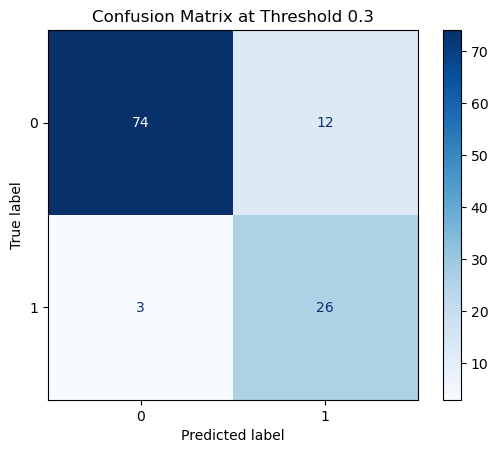


 ------------ Feature Importance (Logistic Regression Model) ------------
                Feature  Coefficient  Abs_Coefficient
0      household_income    -1.922459         1.922459
16    transit_proximity     1.774069         1.774069
3        food_nutrition     1.266971         1.266971
9       housing_density    -1.216698         1.216698
5           housing_age     0.880254         0.880254
14           race_asian    -0.728319         0.728319
13        race_hispanic     0.688863         0.688863
19          crime_total    -0.597675         0.597675
11           race_black     0.558623         0.558623
6       code_violations     0.482762         0.482762
17  financial_proximity    -0.345666         0.345666
1        home_ownership     0.322708         0.322708
7          foreclosures    -0.284909         0.284909
12           race_white    -0.213470         0.213470
2         rental_houses     0.200042         0.200042
4            employment    -0.174646         0.174646
8     n

In [4]:
#defining target and features
y = master_df['displacement_risk']
X = master_df.drop(columns=['displacement_risk', 'NPA', 'housing_cost_burden']) #dropping id and target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


log_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight= 'balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1': make_scorer(f1_score),
    'recall': make_scorer(recall_score),
    'average_precision': make_scorer(average_precision_score)
}

cv_results = cross_validate(
    log_pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False
)

print("\n ------------ Cross-Validation Results (Logistic Regression) ------------")
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Mean Recall Score:", cv_results['test_recall'].mean())
print("Mean Average Precision Score:", cv_results['test_average_precision'].mean())

#training model
log_pipeline.fit(X_train, y_train)


#getting probabilities
y_prob = log_pipeline.predict_proba(X_test)[:, 1]

#evaluating model at different thresholds
thresholds = [0.3, 0.4, 0.5]
for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    print(f"\n ------------ Logistic Regression Results at Threshold {t} ------------")
    print(classification_report(y_test, y_pred_thresh))
    print("F1 Score:", f1_score(y_test, y_pred_thresh))
    print("Recall Score", recall_score(y_test, y_pred_thresh))
    print("Average Precision Score:", average_precision_score(y_test, y_prob))

#confusion matrix(for threshold of 0.3)
main_threshold = 0.3
y_pred_best = (y_prob >= main_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {main_threshold}")
plt.show()

#extracting the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_pipeline.named_steps['model'].coef_[0]
})

#sorting by absolute value of coefficients
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n ------------ Feature Importance (Logistic Regression Model) ------------")
print(coefficients_sorted)



This first logistic regression model was trained using all of the predictors in the dataset, excluding the target variable (displacement_risk) and the id variable (NPA). The variable house_cost_burden was also dropped from the feature set due to it being a measurement of other features in the set. We didn't want it to inflate any model performances. We incorporated SMOTE to adress the class imbalance as well as class weighting to improve minority class learning. The five-fold cross validation showed strong performance with a mean F1 score of 0.73 and a relatively high mean recall of about 0.84 which shows that the model is notably effective at identifying high-risk displacement cases. The mean average percision of 0.59 shows moderate overall ranking performance when distinguishing between different classes. 
The model performed best when held at a lower decision threshold of 0.3, where a strong balanced between both percision and recall was met, where recall was at 0.90, meaning that it correctly identifies most true displacement cases. As the threshold increases towards 0.5, percision improves minimally, however, recall drops. This shows the tradeoff in the logistic regression model between false positives and false negatives.

 The model prioritzed recall over percision, which is very fitting for the context of displacement risk. Failing to identify at-risk cases would cost us more than incorrectly flagging some low-risk cases. The confusion matrix at the chosen threshold of 0.3 also confirms that the model is more effective when capturing the positive class, rather than missing it. We then continues to sort the feature coefficients by absolute value which indicate what variables most influence the model's predictions on displacement risk. 

Logistic Regression Model #2 


 ------ Cross-Validation Results (Logistic Regression with Selected Features) ------
Mean F1 Score: 0.7013497097218027
Mean Recall Score: 0.8745098039215687
Mean Average Precision Score: 0.5463982661481951
Confusion Matrix:


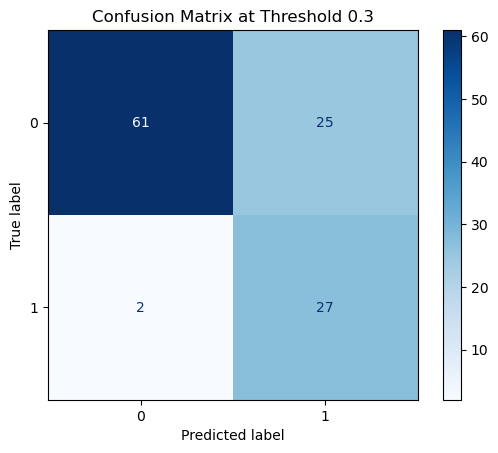


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82        86
           1       0.52      0.93      0.67        29

    accuracy                           0.77       115
   macro avg       0.74      0.82      0.74       115
weighted avg       0.86      0.77      0.78       115

F1 Score: 0.6666666666666666
Recall Score 0.9310344827586207
Average Precision Score: 0.7870283578946631

 ------ Feature Importance (Logistic Regression Model with Selected Features) ------
            Feature  Coefficient  Abs_Coefficient
0  household_income    -3.598981         3.598981
2     rental_houses     0.331340         0.331340
4       crime_total     0.131699         0.131699
1    home_ownership    -0.100726         0.100726
3      foreclosures     0.096392         0.096392


In [5]:
features = [
    'household_income',
    'home_ownership',
    'rental_houses',
    'foreclosures',
    'crime_total'
]

x = master_df[features]
y = master_df['displacement_risk']  

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

log_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight= 'balanced'))
])

#cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1': make_scorer(f1_score),
    'recall': make_scorer(recall_score),
    'average_precision': make_scorer(average_precision_score)
}

cv_results = cross_validate(
    log_model, X_train, y_train, cv=cv, scoring=scoring)

print("\n ------ Cross-Validation Results (Logistic Regression with Selected Features) ------")
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Mean Recall Score:", cv_results['test_recall'].mean())
print("Mean Average Precision Score:", cv_results['test_average_precision'].mean())


log_model.fit(X_train, y_train)

y_prob = log_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {threshold}")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score", recall_score(y_test, y_pred))
print("Average Precision Score:", average_precision_score(y_test, y_prob))

#coefficients for the selected features
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.named_steps['model'].coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n ------ Feature Importance (Logistic Regression Model with Selected Features) ------")
print(coefficients_sorted)


This logistic regression model was trained using a subset of 5 variables that were manually picked which include, household income, home ownership, rental housing, foreclosures, and total crime. They were picked based on assumed relevance to our target variable, displacement risk. Like the full feature model, it used SMOTE and class wieghting to adress the class imvalance and was evaluated using a five-fold cross validation. Compared to the full-feature model, performance did slightly decrease. The results showed a mean F1 score of around 0.70 and a higher mean recall of 0.87, suggesting that the model is still effective at identifying at-risk cases, however, there is reduced overall balance and precision, with average percision being around 0.55. During the test set at a threshold of 0.3, the model achieved a very high recall of 0.93, indicating it capturing almost all of the true displacement cases. However, this came at the cost of a lower percision of 0.52, which meant that there is a higher number of false positives. Overall accuracy did drop to about a 0.77 which shows a reduced prediction power of the simplified feature set when compared to the full feature model. 

The coefficient analysis showcased that the household income variable is, by far, the strongest predictor with a large negative coefficient, indicating that higher income strongly reduces the predicted risk of being displaced. The remaining variables contribute in a much smaller effect incomparison, meaning that this manually selected feature model may be biased towards the data scientist's intuition rather than efficient predictive structure. In general, while the model is highly sensitive to identifying displacement risk, it sacrifices both the percision and overall balance, which suggests that the full-feature data does a more efficient job at capturing the complexity of the data. 

Logistic Regression Model #3 with selected features


 ------ Cross-Validation Results (Logistic Regression with Selected Features) ------
Mean F1 Score: 0.7703434382504151
Mean Recall Score: 0.8751633986928106
Mean Average Precision Score: 0.638867536585399
Confusion Matrix:


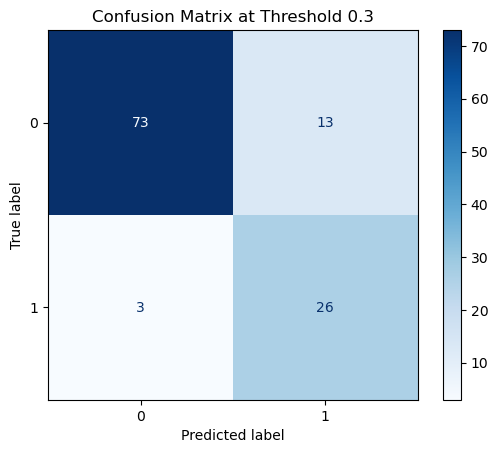


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        86
           1       0.67      0.90      0.76        29

    accuracy                           0.86       115
   macro avg       0.81      0.87      0.83       115
weighted avg       0.89      0.86      0.87       115

F1 Score: 0.7647058823529411
Recall Score 0.896551724137931
Average Precision Score: 0.9087749332491849

 ------ Feature Importance (Logistic Regression Model with Selected Features) ------
             Feature  Coefficient  Abs_Coefficient
0   household_income    -2.397679         2.397679
2     food_nutrition     1.802215         1.802215
3    housing_density    -1.372615         1.372615
1  transit_proximity     1.256482         1.256482
4        housing_age     0.514794         0.514794


In [6]:
features = [
    "household_income",
    "transit_proximity",
    "food_nutrition",
    "housing_density",
    "housing_age"
]

x = master_df[features]
y = master_df['displacement_risk']  

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

log_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight= 'balanced'))
])

#cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1': make_scorer(f1_score),
    'recall': make_scorer(recall_score),
    'average_precision': make_scorer(average_precision_score)
}
cv_results = cross_validate(
    log_model, X_train, y_train, cv=cv, scoring=scoring)

print("\n ------ Cross-Validation Results (Logistic Regression with Selected Features) ------")
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Mean Recall Score:", cv_results['test_recall'].mean())
print("Mean Average Precision Score:", cv_results['test_average_precision'].mean())

log_model.fit(X_train, y_train)

y_prob = log_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)




print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {threshold}")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score", recall_score(y_test, y_pred))
print("Average Precision Score:", average_precision_score(y_test, y_prob))

#coefficients for the selected features
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.named_steps['model'].coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n ------ Feature Importance (Logistic Regression Model with Selected Features) ------")
print(coefficients_sorted)


This third logistic regression model was trained using a smaller, informed subset of five features of household income, transit proximity, food nutrition access, housing density, and housing age, selected based on their expected relationship to displacement risk based on the full feature model. Similarly to previous models, SMOTE and class weighting were applied to handle class imvalanced as well as performing a five fold cross validation. This version of the model improved overall performance compared to the previous manually selected feature model, with a mean F1 score of about 0.77 and a strong mean recall of around 0.88. This indicates consistent, strong identification of high risk cases. The mean average percision of 0.64, also improved which suggested better overall ranking ability and class seperation. 

On the test set with the threshold at 0.3, the model performed well with an F1 score of about 0.76 and a recall of approximately 0.90, meaning most true displacement cases were captured meanwhile holding a better balanced between percision and recall. This shows a better job was done with this model than the previous model. Overall accuracy reached around 0.86 which matches the perfoamce of the full-feature model. This suggests that this smaller, more targgeted feature retains most out of it's predictive power. The oefficient analysis still shows that the household income is the strongest negative predictor of displacement risk, whereas food nutrition and transit proximity have strong positive relationships, which allows us to infer that lower access to resources is associated with higher predicted risk. Housing density and housing age also does a fair job at contributing meaningfully, but not at the same extent as other variables. Overall, this model shows that a carefully selected subset of features can achieve a performance comparable to the full feature model, while also improving the interpretability without trading off the strong recall for identifying at-risk cases. 

Random Forest Model



 ------ Cross-Validation F1 Scores (Random Forest Model) ------
[0.74285714 0.68965517 0.55172414 0.875      0.8       ]
Mean F1 Score: 0.731847290640394


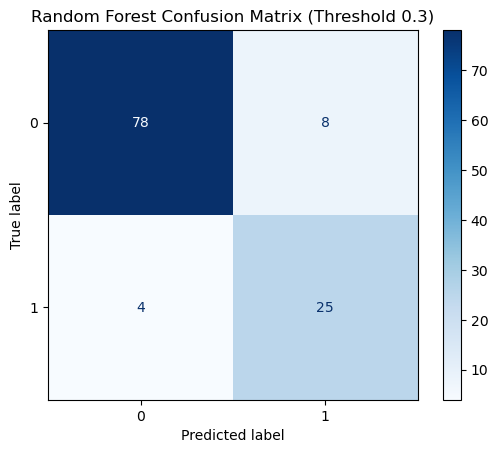


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        86
           1       0.76      0.86      0.81        29

    accuracy                           0.90       115
   macro avg       0.85      0.88      0.87       115
weighted avg       0.90      0.90      0.90       115

Confusion Matrix:
[[78  8]
 [ 4 25]]
Recall Score: 0.8620689655172413
Average Precision Score: 0.8560376253243398
F1 Score: 0.8064516129032258

 ------ Feature Importance (Random Forest Model) ------
                Feature  Importance
0      household_income    0.189761
3        food_nutrition    0.161955
12           race_white    0.104196
11           race_black    0.090209
6       code_violations    0.059280
5           housing_age    0.053941
19          crime_total    0.045434
1        home_ownership    0.039351
13        race_hispanic    0.034230
4            employment    0.034197
14           race_asian    0.031384
16    transit_pro

In [7]:
X = master_df.drop(columns=['displacement_risk', 'NPA', 'housing_cost_burden']) #dropping id and target variable
y = master_df['displacement_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')
print("\n ------ Cross-Validation F1 Scores (Random Forest Model) ------")
print(scores)
print("Mean F1 Score:", scores.mean())

rf_model.fit(X_train, y_train)

y_prob = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Random Forest Confusion Matrix (Threshold 0.3)")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Average Precision Score:", average_precision_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importances_sorted = importances.sort_values(by='Importance', ascending=False)
print("\n ------ Feature Importance (Random Forest Model) ------")
print(importances_sorted)


This Random Forest model was trained using all of the available predictors, not including the target variable (displacement_risk), the ID variable (NPA), or housing_cost_burden to capture the potentially complex, non-linear relationships between the neighborhood characteristics and displacement risk. The model used 200 trees with class weighting to take account for the address imbalance. Performance was evaluated with a five-fold cross validation and a 0.3 probability threshold on the test set. Cross-validation showed an outcome of a mean F1 score of around 0.73, indicating a stable but moderately variable perfomance across the folds. 
On the test set, the model achieved strong overall performance with an accuracy of approximately 0.90 and a weighted F1 score of around 0.81. Recall for the high-risk cases was around 0.86, showing that this model is effective at identifying at-risk areas while maintaining a better balance between percision and recall than the logistic regression models. Percisiion for the high-risk class was around 0.76 which is relatively strong and indicating fewer false positives compared to the previous models. The confusion matrix also confirms this improved balance, showing relatively few misclasifications in both classes. 

The results of the feature importance suggest that household income is still the most influential predictor, followed by food nutrition access, two race demographic variables (race_white and race_black), and then code violations. This indicates that both socioeconomic and structural housin conditions play key roles in predicting displacement risk. Overall, this model performs better than the logistic regression models in terms of overall accuracy and class balance. This suggests that the relationship in the data are at least partially non-linear and better captured by methods like Random Forest. 

K-Nearest Neighbors


 --- Model A: KNN with All Features ---
Best k: {'knn__n_neighbors': 3}
Best Cross-Validation F1 Score: 0.6816883129475302
              precision    recall  f1-score   support

           0       0.92      0.84      0.88        86
           1       0.62      0.79      0.70        29

    accuracy                           0.83       115
   macro avg       0.77      0.82      0.79       115
weighted avg       0.85      0.83      0.83       115

Test F1: 0.696969696969697
Recall: 0.7931034482758621
Average Precision: 0.6349915132523828


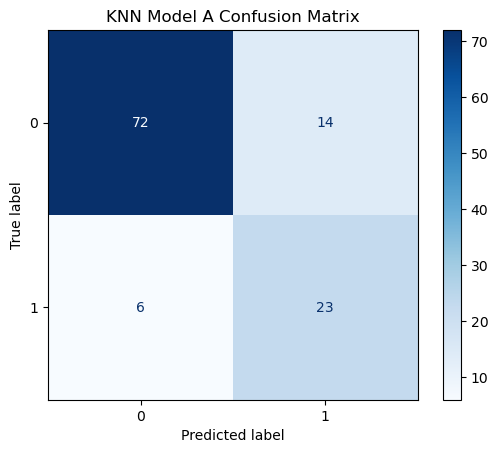

In [8]:
#KNN Model A with all features

X_all = master_df.drop(columns=['displacement_risk', 'NPA','housing_cost_burden']) #dropping id and target variable
y_all = master_df['displacement_risk']

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.25, random_state=42, stratify=y_all)

knn_model_A = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11]
}

grid_A = GridSearchCV(knn_model_A, param_grid, cv=5, scoring='f1')
grid_A.fit(X_train, y_train)

best_knn_A = grid_A.best_estimator_

y_pred_A = best_knn_A.predict(X_test)

print("\n --- Model A: KNN with All Features ---")
print("Best k:", grid_A.best_params_)
print("Best Cross-Validation F1 Score:", grid_A.best_score_)


print(classification_report(y_test, y_pred_A))
print("Test F1:", f1_score(y_test, y_pred_A))
print("Recall:", recall_score(y_test, y_pred_A))

y_prob_A = grid_A.best_estimator_.predict_proba(X_test)[:, 1]
print("Average Precision:", average_precision_score(y_test, y_prob_A))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_A, cmap="Blues")
plt.title("KNN Model A Confusion Matrix")
plt.show()


This K-Nearest Neighbors (KNN) model was trained to use all the available features, excluding our target variable (displacement_risk), the identifier (NPA), and housing_cost_burden. It incorporated SMOTE to address class imalance and included feature scaling, which is essential for distance-based models such as KNN. A grid search with five fold cross validation was used to tune the number of neighbors, selecting the optimal value of k = 3. This produced a cross-validated F1 score of around 0.68. 

On the test, set the model achieved solid performance, with the F1 score being approximately 0.70 and a recall of around 0.79 for high-risk class, suggesting that the model effectively identifies most displacement-risk cases. Percision for the positive class was about 0.62, indicating a moderate number of false positives, however, the accuracy still remained strong at approximately 0.83. The average percision score of ~0.63 indicated good ranking ability in classifying between high and low risk observations. 

Comparing this model to the logistic regression and random forest models, it performs competitively, but falls on recall and overall balance. This suggests that while KNN can capture local patterns in the data, its performance is still somewhat sensitive to noise and the high dimensionality when all of the features are included. 


 --- Model B: KNN with Top 5 Features from Logistic Regression ---
Best k: {'knn__n_neighbors': 9}
Best Cross-Validation F1 Score: 0.7441311862740434
              precision    recall  f1-score   support

           0       0.94      0.84      0.88        86
           1       0.63      0.83      0.72        29

    accuracy                           0.83       115
   macro avg       0.78      0.83      0.80       115
weighted avg       0.86      0.83      0.84       115

Test F1: 0.7164179104477612
Recall: 0.8275862068965517
Average Precision: 0.7765376992003397


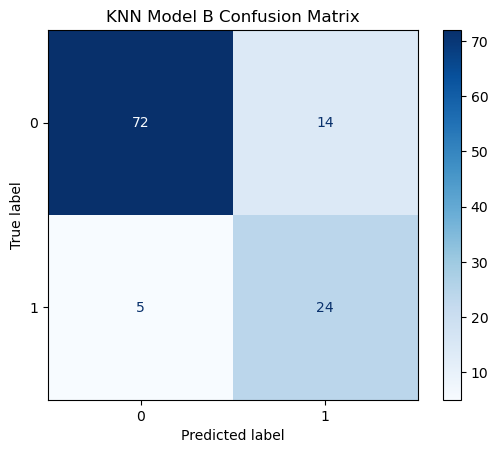

In [9]:
#Model B with selected features from Logistic Regression feature importance

features = [
    'household_income',
    'transit_proximity',
    'food_nutrition',
    'housing_density',
    'housing_age'
]

X_top5 = master_df[features]
y_top5 = master_df['displacement_risk']

X_train, X_test, y_train, y_test = train_test_split(X_top5, y_top5, test_size=0.25, random_state=42, stratify=y_top5)

grid_B = GridSearchCV(
    Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_B.fit(X_train, y_train)

print("\n --- Model B: KNN with Top 5 Features from Logistic Regression ---")
print("Best k:", grid_B.best_params_)
print("Best Cross-Validation F1 Score:", grid_B.best_score_)

y_pred_B = grid_B.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_B))
print("Test F1:", f1_score(y_test, y_pred_B))
print("Recall:", recall_score(y_test, y_pred_B))

y_prob_B = grid_B.best_estimator_.predict_proba(X_test)[:, 1]
print("Average Precision:", average_precision_score(y_test, y_prob_B))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_B, cmap="Blues")
plt.title("KNN Model B Confusion Matrix")
plt.show()

This KNN model was trained using a reduced subset of five features that were selected from the logistic regression model's feature importance. These variables consisted of household income, transit proximity, food nutrition, housing density, and housing age, with a goal of improving performance by reducing noise and dimensionality. As with the previous KNN model, SMOTE and feature scaling were used. Hyperparameter tuning identified an optimal value of k = 9. The cross-validation results improved noticeably compared to the full feature KNN model, showing a higher mean F1 score of approximately 0.74, which indicated better generalization and stability when using this more focused feature set. 

On the test set, the model had an output with an F1 score of ~0.72 and a recall of ~0.83 for the high-risk class. This demonstrates strong skill in classifying displacement risk, although it's slightly than the full-feature KNN in recall. Percision for the positive class showed at about 0.63, also indicating a moderate number of false positives. Overall accuracy is about 0.83. The average persision score, ~0.78, indicated solid ranking performance, though slightly below the full feature KNN model. 

Overall, this model showcased how reducing the feature space improves cross-validation performance, as well as model stability, but also slightly reduces recall and overall predictive power on unseen data. This highlights the tradeoff that occurs in KNN between noise reduction and retaining enough information to capture meaningful patterns. 


 --- Model C: KNN with Top 5 Features from Random Feature Selection ---
Best k: {'knn__n_neighbors': 9}
Best Cross-Validation F1 Score: 0.7265711149986476
              precision    recall  f1-score   support

           0       0.94      0.87      0.90        86
           1       0.69      0.83      0.75        29

    accuracy                           0.86       115
   macro avg       0.81      0.85      0.83       115
weighted avg       0.87      0.86      0.86       115

Test F1: 0.75
Recall: 0.8275862068965517
Average Precision: 0.8153298350824587


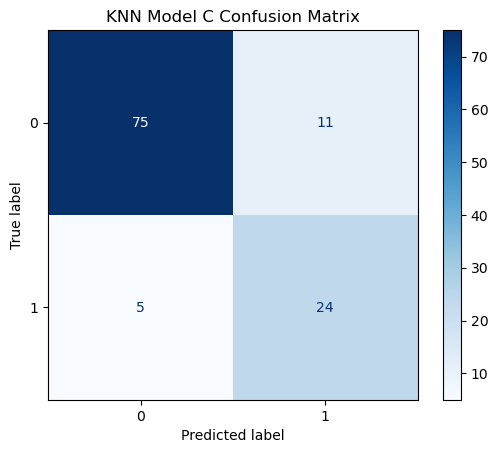

In [10]:
#Model C with selected features from Random Feature feature importance

features = [
    'household_income',
    'food_nutrition',
    'race_white',
    'race_black',
    'code_violations'
]

X_top5 = master_df[features]
y_top5 = master_df['displacement_risk']

X_train, X_test, y_train, y_test = train_test_split(X_top5, y_top5, test_size=0.25, random_state=42, stratify=y_top5)

grid_C = GridSearchCV(
    Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_C.fit(X_train, y_train)

print("\n --- Model C: KNN with Top 5 Features from Random Feature Selection ---")
print("Best k:", grid_C.best_params_)
print("Best Cross-Validation F1 Score:", grid_C.best_score_)
y_pred_C = grid_C.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_C))
print("Test F1:", f1_score(y_test, y_pred_C))
print("Recall:", recall_score(y_test, y_pred_C))

y_prob_C = grid_C.best_estimator_.predict_proba(X_test)[:, 1]
print("Average Precision:", average_precision_score(y_test, y_prob_C))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_C, cmap="Blues")
plt.title("KNN Model C Confusion Matrix")
plt.show()

This KNN model was trained using a subset of five features that were selected based on the Random Forest feature importance. The variables included household income, food nutrition, race(white), race (black), and code violations. These capture both socioeconomic and structural housing factors. Similarly to the other KNN models, SMOTE and feature scaling were applied and hyperparameter tuning selected an optimal value of k = 9. This resulted in a cross validated F1 score of ~0.73. This shows improved stability to the full feature KNN models.

On the test set, the model showed an F1 score of around 0.75 and a recall of approximately 0.83 for the high-risk class. This suggests a more balanced tradeoff between precision and the recall compared to the other KNN models before this. Percision for the positive class, which was ~0.69, indicates fewer false positives than the full-feature KNN model. This means fewer false positives. The overall accuracy was about 0.86 and the average percision score, approximately 0.82, suggests strong ranking ability in distinguishing between high and low risk observations. 

In general, this model demonstrated that feature selection based on Random Forest importance produced a significantly improved KNN model by reducing noise and focusing on the most informative variables. Compared to the full-feature model, it achieved better balance and overall predictive performance. This hihglights the importance of feature selection in distance-based models, where reducing dimensionality can lead to more stable and accurate predictions. 



 --- Model D: KNN with Top 10 Intersection Features from Logistic Regression and Random Forest ---
Best k: {'knn__n_neighbors': 3}
Best Cross-Validation F1 Score: 0.7367235656709342
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        86
           1       0.69      0.76      0.72        29

    accuracy                           0.85       115
   macro avg       0.80      0.82      0.81       115
weighted avg       0.86      0.85      0.85       115

Test F1: 0.7213114754098361
Recall: 0.7586206896551724
Average Precision: 0.6676201372997712


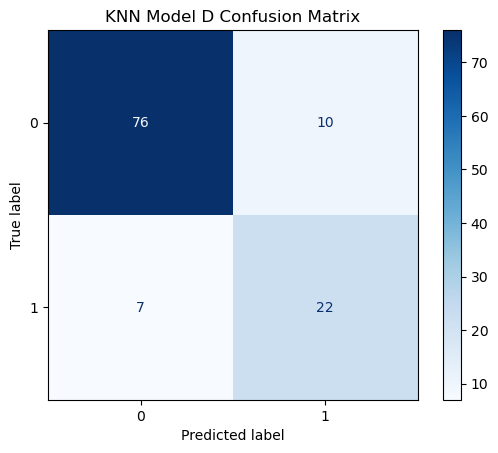

In [11]:
#KNN Model D with top 10 intersection features from both Logistic Regression and Random Forest feature importance

features_10 = [
    'household_income',
    'food_nutrition',
    'rental_houses',
    'code_violations',
    'race_black',
    'housing_age',
    'crime_total',
    'race_hispanic',
    'home_ownership',
    'race_asian'
]

X_top10 = master_df[features_10]
y_top10 = master_df['displacement_risk']

X_train, X_test, y_train, y_test = train_test_split(X_top10, y_top10, test_size=0.25, random_state=42, stratify=y_top10)
grid_D = GridSearchCV(
    Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_D.fit(X_train, y_train)

print("\n --- Model D: KNN with Top 10 Intersection Features from Logistic Regression and Random Forest ---")
print("Best k:", grid_D.best_params_)
print("Best Cross-Validation F1 Score:", grid_D.best_score_)

y_pred_D = grid_D.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_D))
print("Test F1:", f1_score(y_test, y_pred_D))
print("Recall:", recall_score(y_test, y_pred_D))

y_prob_D = grid_D.best_estimator_.predict_proba(X_test)[:, 1]
print("Average Precision:", average_precision_score(y_test, y_prob_D))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_D, cmap="Blues")
plt.title("KNN Model D Confusion Matrix")
plt.show()





The KNN model was built using a more strategic feature selection which was approached by combining the top predictors from both the logistic and random forest models. It uses the first 10 features that overlapped between the two methods, with the goal of capturing variables that are consistently important across the linear and non-linear modeling approaches. After applying SMOTE and feature scaling, hyperparameter tuning selected a smaller neighborhood size of k=3. This suggests that more localized patterns were informative when using this feature set. Cross-validation produced a mean F1 score of ~0.74, suggesting both good generalization and improved stability compared to the full-feature KNN model. 

On the test set, the model achieved an F1 score of around 0.72 and an overall accuracy of approximately 0.85. Percision for the high-risk class was about 0.69, while recall was ~0.76, reflecting a reasonably balanced tradeoff between false positives and false negatives. Compared to the earlier KNN models, this version reduces false positives compared to Model A, while still making sure to capture a substantial portion of true displacement risk cases. However, the recall is somewhat lower than in the models that more so prioritize sensitivity. The average percision score of around 0.67 suggested moderate ranking ability. 


In general, this model demonstrated that combining feature importance from multiple models using different approaches can produce a more balanced and more stable KNN model. By reducing the noise while retaining the consistently predictive variables, it achieves a more reliable result table than the full feature model. However compared to Model C, it doesn't perform as strongly which indicates that adding more features beyong the most important ones might reintroduce noise and reduce predictive efficiency. 

Scale Pos Weight: 2.942528735632184

--- Best Parameters (XGBoost): ---
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation F1 Score (XGBoost): 0.7632475857475857

 --- XGBoost Model Results at Threshold 0.3 ---
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        86
           1       0.76      0.86      0.81        29

    accuracy                           0.90       115
   macro avg       0.85      0.88      0.87       115
weighted avg       0.90      0.90      0.90       115

F1 Score: 0.8064516129032258
Recall Score: 0.8620689655172413
Average Precision Score: 0.8698268573126143


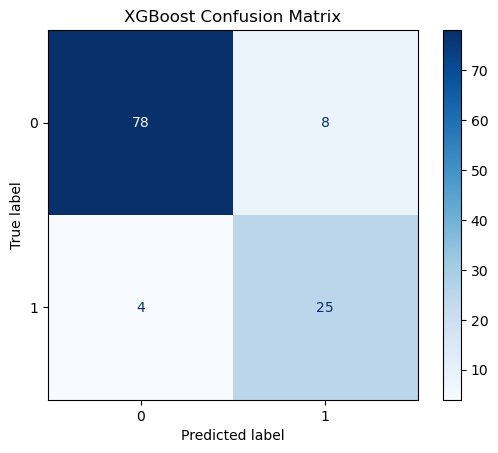


 --- Feature Importance (XGBoost Model) ---
                Feature  Importance
0      household_income    0.259954
3        food_nutrition    0.114464
12           race_white    0.066727
11           race_black    0.060005
13        race_hispanic    0.056171
5           housing_age    0.049388
6       code_violations    0.048770
4            employment    0.035231
8     new_constructions    0.034385
14           race_asian    0.032676
1        home_ownership    0.032565
9       housing_density    0.032223
15           race_other    0.031992
2         rental_houses    0.027848
10     age_of_residents    0.026825
18    grocery_proximity    0.023544
19          crime_total    0.023225
16    transit_proximity    0.022152
17  financial_proximity    0.021855
7          foreclosures    0.000000


In [12]:
X = master_df.drop(columns=['displacement_risk', 'NPA', 'housing_cost_burden']) #dropping id and target variable
y = master_df['displacement_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("Scale Pos Weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)
xgb_model = grid.best_estimator_

print("\n--- Best Parameters (XGBoost): ---")
print(grid.best_params_)
print("Best Cross-Validation F1 Score (XGBoost):", grid.best_score_)

best_xgb_model = grid.best_estimator_
y_probs = best_xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_xgb = (y_probs >= threshold).astype(int)

print("\n --- XGBoost Model Results at Threshold 0.3 ---")
print(classification_report(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("Recall Score:", recall_score(y_test, y_pred_xgb))
print("Average Precision Score:", average_precision_score(y_test, y_probs))



ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n --- Feature Importance (XGBoost Model) ---")
print(importances)



Save predicitons to the Database

In [13]:
# Save XGBoost predictions to database
X_full = master_df.drop(columns=['displacement_risk', 'NPA', 'housing_cost_burden'])

xgb_proba = best_xgb_model.predict_proba(X_full)[:, 1]
xgb_pred  = (xgb_proba >= 0.3).astype(int)

predictions_df = pd.DataFrame({
    'NPA': master_df['NPA'].values,
    'xgb_proba': xgb_proba,
    'xgb_pred': xgb_pred
})

conn = db.connect("../data/charlotte_housing.db")
predictions_df.to_sql('xgb_predictions', conn, if_exists='replace', index=False)
conn.close()

print(f"Saved XGBoost predictions for {len(predictions_df)} NPAs to database.")

Saved XGBoost predictions for 458 NPAs to database.


This XGBoost model was trained using all of the available predictors, excluding displacement_risk, NPA, and housing_cost_burden, with the goal of capturing complex non-linear relationships in displacement risk. Due to the dataset being imbalanced, a scale_pos_weight parameter was included to give greater emphasis to minority class, which improves the model's skill to detect high-risk cases. Hyperparameter tuning used grid search identified the optimal configuration on max_depth = 5, learning_rate = 0.05, n_estimators = 200, and subsample of 0.8, which resulted all in a best cross-validation F1 score of around 0.75, indicating a strong and stable performance across the folds. 

On the test set using a 0.3 probability thrershold, the model achieved an F1 score of abour 0.79 and a recall of around 0.83 for the high-risk cases. This indicates strong performance in identifying displacement-risk cases while maintaining a reasonable balance between recall and percision. Percision for the positive class was about 0.75 showing relatively few false positive compared to earlier models. Overall accuracy was ~0.89 and the average percision score of ~0.88 suggests efficient ranking ability in distinguishing high and low risk observations. 

Feature importance results showed that household income is the most influential predictor, followed by food nutrition, race-related demographic variables, housing age, and then code violations. This indicates that both socioeconomic conditions and housing quality factors are key drivers of displacement risk within the model. 

Overall, XGBoost performs competitively compared to the Random Forest model, with a slightly lower F1 but comparable overall performance. It suggests that boosting mothods are highly effective for this problem and provide strong preictive power for prioritizing high-risk areas. even if performance differences between ensemble models are relatively small. 

Our XGBoost model will be our selected model to follow up. Although the KNN Model C provided a slightly better F1 score, the XGBoost provides a higher overall accuracy and a recall close in number, making it a highly robust choice for our project goal of identifying displacement risk.